In [199]:
import numpy as np 
import matplotlib.pyplot as plt 

from scipy.integrate import quad
from scipy.integrate import fixed_quad

In [200]:
def Rp_m_l(l, p, theta, psi):
    return np.sqrt(l**2 + p**2 - 2*p*l*np.cos(theta - psi))
    #return -np.cos(theta - psi) * p + (1 - np.cos(theta - psi)**2) * p**2 / (2*l) + l

def Rp_m_l_approx(l, p, theta, psi):
    return -np.cos(theta - psi) * p + (1 - np.cos(theta - psi)**2) * p**2 / (2*l) + l

def Rp_m_l_smalll(l, p, theta, psi):
    return p - np.cos(theta - psi) * l + np.sin(theta - psi)**2 * l**2 / (2*p)


def VHO_eff(q, mu):
    eps = mu
    exp_term = np.exp(-q*q / (2 * eps*eps))

    fac = 1.0 / (2.0 * np.pi * eps**4) * (q*q  / (eps*eps)  - 2.0)

    return exp_term * fac

In [201]:
def f(r):
    return 3*r**2

def integrand(r):
    return 2 * np.pi * r * f(r) * VHO_eff(r, 0.01)

fixed_quad(integrand, 0, 0.05, n = 20)[0]

np.float64(11.99240880748846)

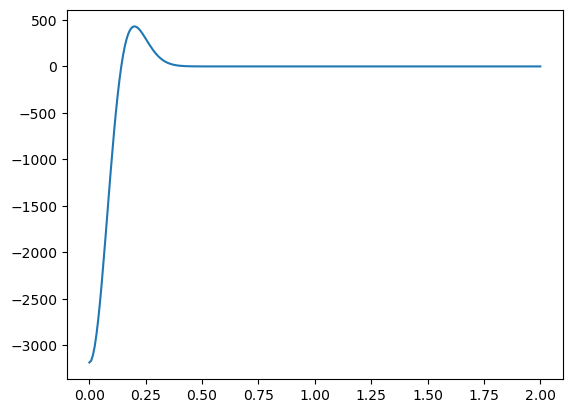

In [202]:
R = np.linspace(0, 2, 256)
plt.plot(R, VHO_eff(R , 0.1))
plt.show()

In [203]:
def moment1(theta, p, l,psi, R):
    return (R(l, p, theta, psi) - l)

def integrated_theta(p, l, psi, R):
    #return fixed_quad(moment1, a= 0, b= 2*np.pi, args=(p, l, psi), n = 10)[0] 

    return fixed_quad(moment1, a= 0, b= 2*np.pi, args=(p, l, psi, R), n = 6)[0] 
    # thetas = np.linspace(0, 2*np.pi, 512)
    # integrand = 0.0
    # for i in range(len(thetas)):
    #     integrand += moment1(thetas[i], p, l, psi, R) * (thetas[1] - thetas[0])
    # return integrand


def integral(l, psi, R):
    #return fixed_quad(integrated_theta, a = 0, b =  0.4, args = (l, psi, R), n = 10)[0]
    #return fixed_quad(integrated_theta, a = 0, b =  0.4, args = (l, psi, R), n = 10)[0]
    # return quad(integrated_theta, a = 0, b = 0.4, args = (l, psi, R), limit = 100)[0]
    p = np.linspace(0, 0.6, 12)
    integrated = 0.0
    w = 1.0
    h = (p[-1] - 0) / (len(p) - 1)
    for i in range(len(p)):
        if i == 0 or i == len(p) - 1:
            w = 1/3
        else:            
            w = 4/3 if i % 2 == 1 else 2/3

        integrated += integrated_theta(p[i], l, psi, R) * w * VHO_eff(p[i], 0.1) * p[i]

    return integrated * h


    #return integrated * (0.4 - 0) / len(p)


# ## fixed quad versions
# def integrated_theta_fixed(p, l, psi, R):
#     return fixed_quad(moment1, a= 0, b= 2*np.pi, args=(p, l, psi, R), n = 10)[0] * p * VHO_eff(p, 0.1)

# def integral_fixed(l, psi, R):
#     return fixed_quad(integrated_theta_fixed, a = 0, b =  0.4, args = (l, psi, R), n = 10)[0]


# ## trapezoidal rule version
# def integrated_theta_trap(p, l, psi, R):
#     theta = np.linspace(0, 2*np.pi, 10000)
#     return np.trapezoid(moment1(theta, p, l, psi, R), theta) * p * VHO_eff(p, 0.1)

# def integral_trap(l, psi, R):
#     p = np.linspace(0, 0.4, 10000)
#     return np.trapezoid(integrated_theta_trap(p, l, psi, R), p)



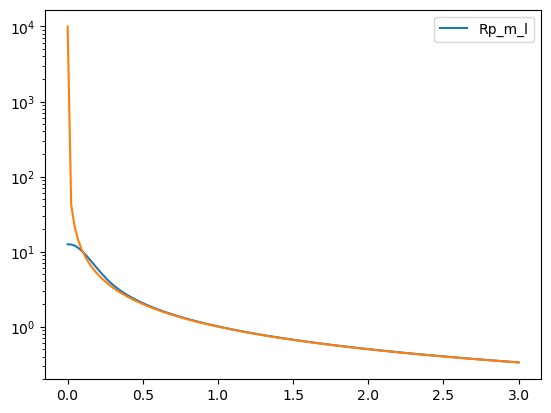

In [204]:
L = np.linspace(0.0001, 3, 128)
#plt.plot(L, [integral(l, 0.5 * np.pi, Rp_m_l_approx) for l in L], label = "Rp_m_l_approx")
#plt.plot(L, [integral(l, 0.5 * np.pi, Rp_m_l_smalll) for l in L], label = "Rp_m_l_smalll")
plt.plot(L, [integral(l, 0.3, Rp_m_l) for l in L], label = "Rp_m_l")
plt.plot(L, 1/L)

plt.yscale("log")
plt.legend()
plt.show()

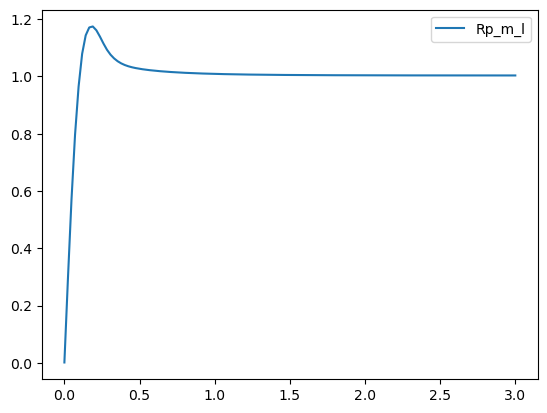

In [205]:
plt.plot(L, [l * integral(l, 0, Rp_m_l) for l in L], label = "Rp_m_l")

plt.legend()
plt.show()

In [206]:
plt.plot(L, np.abs([integral_fixed(l, 0.5 * np.pi, Rp_m_l) for l in L]), label = "|integral_fixed|")
plt.plot(L, np.abs([integral_trap(l, 0.5 * np.pi, Rp_m_l) for l in L]), label = "|integral_trap|")
plt.plot(L, np.abs([integral(l, 0.5 * np.pi, Rp_m_l) for l in L]), label = "Rp_m_l")


plt.yscale("log")
plt.legend()
plt.show()

#for the approximations

plt.plot(L, np.abs([integral_fixed(l, 0.5 * np.pi, Rp_m_l_approx) for l in L]), label = "|integral_fixed|")
plt.plot(L, np.abs([integral(l, 0.5 * np.pi, Rp_m_l_approx) for l in L]), label = "Rp_m_l_approx")

plt.yscale("log")
plt.legend()
plt.show()

plt.plot(L, np.abs([integral_fixed(l, 0.5 * np.pi, Rp_m_l_smalll) for l in L]), label = "|integral_fixed|")
plt.plot(L, np.abs([integral(l, 0.5 * np.pi, Rp_m_l_smalll) for l in L]), label = "Rp_m_l_smalll")

plt.yscale("log")
plt.legend()
plt.show()

NameError: name 'integral_fixed' is not defined

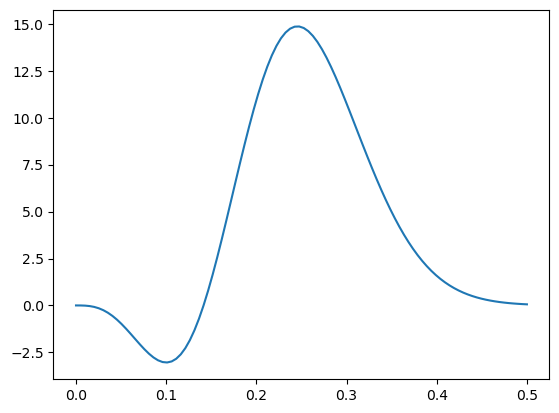

np.float64(2.043027640960937)

In [ ]:
p = np.linspace(0, 0.5, 100)
fp = .0 * p

for i in range(len(p)):
    fp[i] = integrated_theta(p[i], 0.5, 0, Rp_m_l)

plt.plot(p, fp)
plt.show()

np.trapezoid(fp, p, dx = p[1] - p[0])